# Combination violin prediction plots for manuscript

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/readii_2_roqc


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from damply import dirs
import pandas as pd

## Global variables

In [47]:
# Negative control name mapping for plots
nc_mapping = {
    'original_full':'Original',    
    'randomized_roi':"ROI - Random",
    'sampled_roi':'ROI - Sample',
    'shuffled_roi':'ROI - Shuffle',
    'randomized_non_roi':'Background - Random',
    'sampled_non_roi':'Background - Sample',
    'shuffled_non_roi':'Background - Shuffle',
    'randomized_full':'Full - Random',
    'sampled_full':'Full - Sample',
    'shuffled_full':'Full - Shuffle'
}

# Negative control name sort order for plots
nc_categories = ['Original', 
                'ROI - Random', 
                'ROI - Sample', 
                'ROI - Shuffle', 
                'Background - Random', 
                'Background - Sample', 
                'Background - Shuffle', 
                'Full - Random', 
                'Full - Sample', 
                'Full - Shuffle']

xtick_labels = [lbl.replace(" - ", "\n") for lbl in nc_categories]

In [21]:
# Palettes for plotting
blue_palette = ['#003396', '#3373C4', '#86CEFA']
grey_palette = ['#4C5C68', '#899097', '#C5C3C6']
grey2_palete = ['#515151', "#737373", '#959595']
vibrant_palette = ['#FF6F40', '#4ECDC4', '#F69C00']

region_palette = ['#D50032', '#009B77', '#005B96'] #ROI, background, full

In [ ]:
['#636EFA', '#EF553B', '#00CC96']

## Aerts OS Signature

In [56]:
signature = "aerts_original"
dataset_name = ['NSCLC-Radiomics_windowed', 'HEAD-NECK-RADIOMICS-HN1_windowed', 'RADCURE_windowed']
split = ['', '', 'TEST']

evaluation_metric = "C-index"
predictions = []

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / split[idx] / "bootstrap_1000" 
   
    for image_predictions_file in sorted(bootstrap_predictions_path.rglob('*.csv')):
        image_type = str(image_predictions_file.stem)
        image_type_predictions = pd.read_csv(image_predictions_file, index_col=0)

        image_type_predictions['dataset'] = dataset.removesuffix("_windowed")
        image_type_predictions['image_type'] = image_type

        predictions.append(
            image_type_predictions
        )

all_preds_df = pd.concat(predictions)

all_preds_df = all_preds_df.replace({"image_type": nc_mapping})
all_preds_df.image_type = pd.Categorical(all_preds_df.image_type,
                                        categories = nc_categories)
all_preds_df = all_preds_df.sort_values('image_type')

/tmp/ipykernel_713738/2107164451.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xtick_labels)


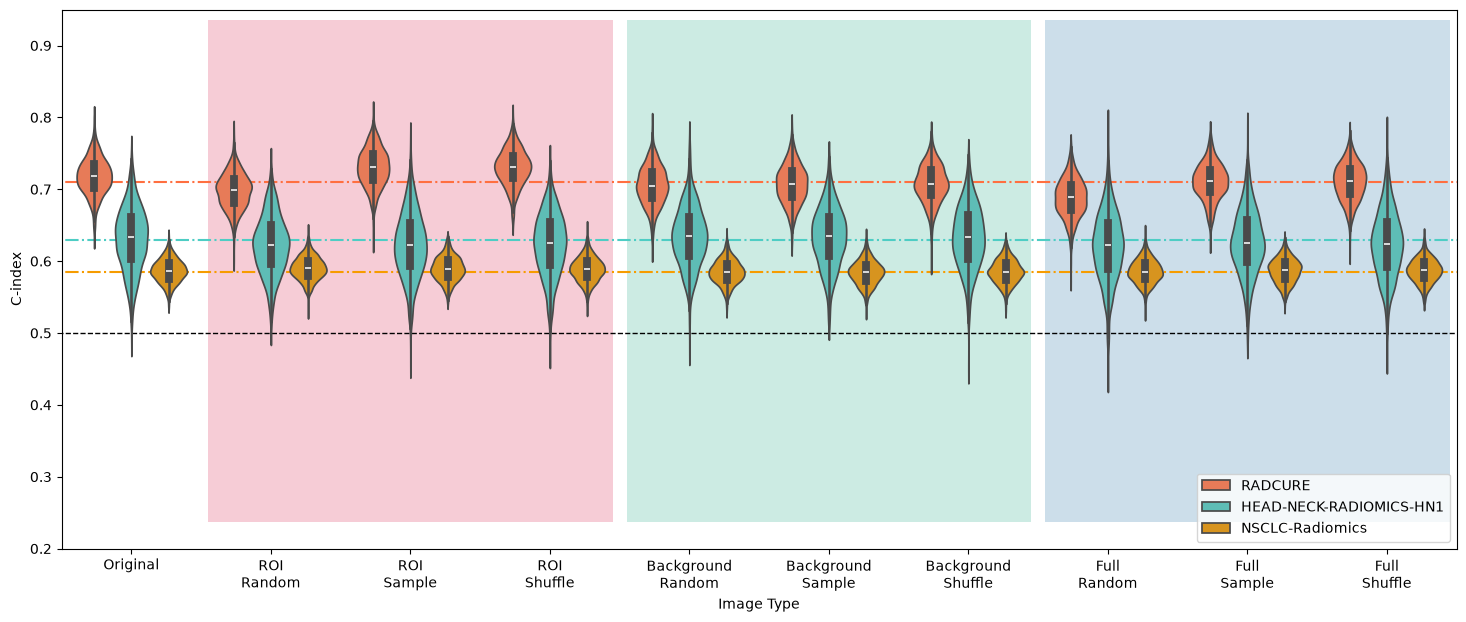

In [58]:
fig, ax = plt.subplots(figsize=(18,7))

# Plot coloured rectangles behind the violins to visualize the negative control regions
yspan_min = 0.05
yspan_max = 0.98
plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# Plot the volume prediction lines for each dataset
plt.hlines(y=[0.710, 0.629, 0.585], xmin=-1, xmax=10, colors=vibrant_palette, linestyles='dashdot', zorder=1)

# Plot random guess line at 0.5
plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# Plot c-index violin plots for each dataset and image type
sns.violinplot(data=all_preds_df, x='image_type', 
               y=evaluation_metric, 
               hue='dataset', 
               hue_order=['RADCURE', 'HEAD-NECK-RADIOMICS-HN1', 'NSCLC-Radiomics'], 
               palette=vibrant_palette,
               gap=0.01
               )

ax.set_ybound(0.2, 0.95)
ax.set_xlabel('Image Type')
ax.set_xticklabels(xtick_labels)
plt.legend(loc='lower right')
plt.show()

## Choi OS Signature

In [59]:
signature = "choi_opc_os_2020"
dataset_name = ['HEAD-NECK-RADIOMICS-HN1_windowed', 'RADCURE_windowed']
split = ['', 'TEST']

evaluation_metric = "C-index"
predictions = []

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / split[idx] / "bootstrap_1000" 
   
    for image_predictions_file in sorted(bootstrap_predictions_path.rglob('*.csv')):
        image_type = str(image_predictions_file.stem)
        image_type_predictions = pd.read_csv(image_predictions_file, index_col=0)

        image_type_predictions['dataset'] = dataset.removesuffix("_windowed")
        image_type_predictions['image_type'] = image_type

        predictions.append(
            image_type_predictions
        )

all_preds_df = pd.concat(predictions)

all_preds_df = all_preds_df.replace({"image_type": nc_mapping})
all_preds_df.image_type = pd.Categorical(all_preds_df.image_type,
                                        categories = nc_categories)
all_preds_df = all_preds_df.sort_values('image_type')

/tmp/ipykernel_713738/2186106301.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xtick_labels)


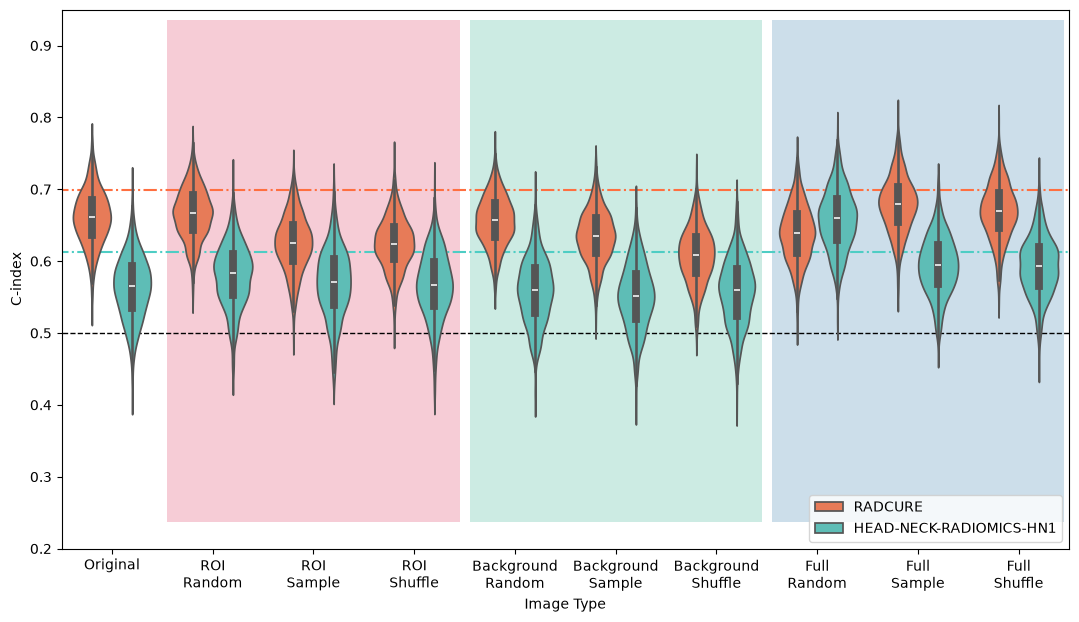

In [60]:
fig, ax = plt.subplots(figsize=(13,7))

# Plot coloured rectangles behind the violins to visualize the negative control regions
yspan_min = 0.05
yspan_max = 0.98
plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# Plot the volume prediction lines for each dataset
plt.hlines(y=[0.699, 0.613], xmin=-1, xmax=10, colors=vibrant_palette[:2], linestyles='dashdot', zorder=1)

# Plot random guess line at 0.5
plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# Plot c-index violin plots for each dataset and image type
sns.violinplot(data=all_preds_df, x='image_type', 
               y=evaluation_metric, 
               hue='dataset', 
               hue_order=['RADCURE', 'HEAD-NECK-RADIOMICS-HN1'], 
               palette=vibrant_palette[:2],
               gap=0.01
               )

ax.set_ybound(0.2, 0.95)
ax.set_xlabel('Image Type')
ax.set_xticklabels(xtick_labels)
plt.legend(loc='lower right')
plt.show()

## Choi HPV Status Signature

Results generated in sandbox/analysis/hpv_prediction.ipynb

In [61]:
signature = "choi_opc_hpv_2020_hpv_status"
dataset_name = ['HEAD-NECK-RADIOMICS-HN1_windowed', 'RADCURE_windowed', 'RADCURE_windowed']
short_data = ['hn1', 'radcure', 'radcure']
split = ['', '_train', '_test']

evaluation_metric = "AUC"
predictions = []

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / f"lr_bootstrap_{short_data[idx]}{split[idx]}.csv"
    bootstrap_predictions = pd.read_csv(bootstrap_predictions_path)

    melt_predictions = bootstrap_predictions.melt(var_name="image_type",
                                                  value_name="AUC")

    # if short_data[idx] == 'radcure':
    #     melt_predictions['dataset'] = f'RADCURE{split[idx]}'
    # else:
    melt_predictions['dataset'] = f"{dataset.removesuffix('_windowed')}{split[idx]}"

    predictions.append(melt_predictions)

all_preds_df = pd.concat(predictions)

all_preds_df = all_preds_df.replace({"image_type": nc_mapping})
all_preds_df.image_type = pd.Categorical(all_preds_df.image_type,
                                        categories = nc_categories)
all_preds_df = all_preds_df.sort_values('image_type')

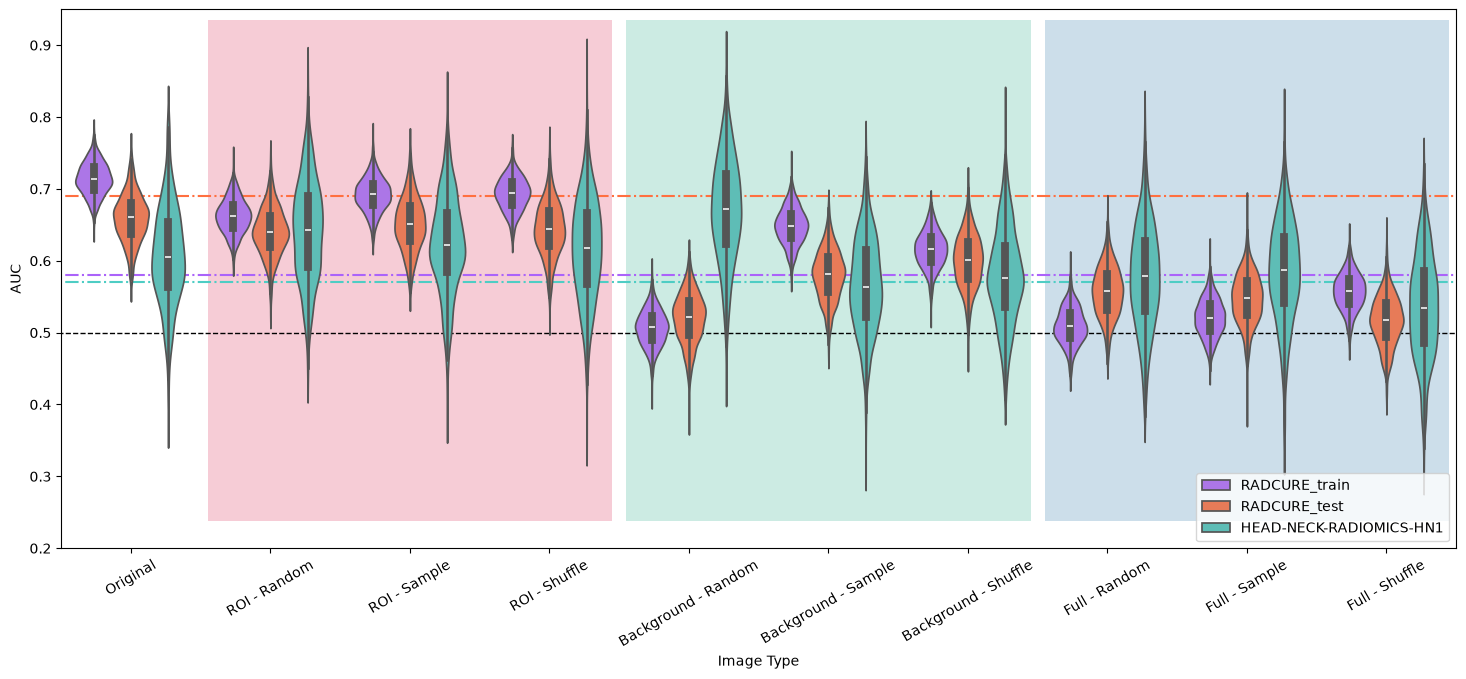

In [54]:
fig, ax = plt.subplots(figsize=(18,7))

p_vibrant = ['#AB63FA'] + vibrant_palette[:2]

# Plot coloured rectangles behind the violins to visualize the negative control regions
yspan_min = 0.05
yspan_max = 0.98
plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# Plot the volume prediction lines for each dataset
plt.hlines(y=[0.58, 0.69, 0.57], xmin=-1, xmax=10, colors=p_vibrant, linestyles='dashdot', zorder=1)

# Plot random guess line at 0.5
plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# Plot c-index violin plots for each dataset and image type
sns.violinplot(data=all_preds_df, x='image_type', 
               y=evaluation_metric, 
               hue='dataset', 
               hue_order=['RADCURE_train', 'RADCURE_test', 'HEAD-NECK-RADIOMICS-HN1'], 
               palette=p_vibrant,
               gap=0.01
               )

ax.set_ybound(0.2, 0.95)
ax.set_xlabel('Image Type')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()